# Sentiment Analysis of IMDb Movie Reviews

This notebook provides a comprehensive sentiment analysis of the IMDb movie review dataset. It covers the entire machine learning pipeline, from data loading and preprocessing to model training, evaluation, and deployment. We will explore both traditional machine learning algorithms and deep learning approaches to classify movie reviews as positive or negative.

# Sentiment Analysis of IMDb Movie Reviews

This notebook performs sentiment analysis on the IMDb movie review dataset. We will go through data loading, preprocessing, exploratory data analysis, feature engineering, model training with traditional machine learning algorithms (Logistic Regression and SVM), hyperparameter tuning, and model evaluation.

In [1]:
import re
import nltk
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

# NLTK for text processing
from nltk.corpus import stopwords

# TensorFlow/Keras for deep learning model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Activation,Dense, Dropout, Embedding, LSTM, Conv1D, GlobalMaxPooling1D, Flatten
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Scikit-learn for model selection and evaluation
from sklearn.model_selection import train_test_split


### Custom Text Preprocessing Utilities

In [2]:
nltk.download('stopwords')
stopwords_list = set(stopwords.words('english'))

# Preserve negation words to ensure they are not removed during preprocessing
negation_words = {
    'no', 'not', 'nor', 'never', 'neither',
    'nobody', 'nothing', 'nowhere', 'hardly',
    'barely', 'scarcely',
    'dont', 'doesnt', 'didnt',     # ← post-regex forms
    'wont', 'wouldnt', 'couldnt',
    'shouldnt', 'isnt', 'arent',
    'wasnt', 'werent'
}

# Remove negation words from the stopwords list
stopwords_list = stopwords_list - negation_words

# Regex to remove HTML tags
TAG_RE = re.compile(r'<[^>]+>')
def remove_tags(text):
    return TAG_RE.sub('', text)

# Custom text preprocessing class
class CustomPreprocess():
    def __init__(self):
        pass

    def preprocess_text(self,sen):
        # Convert text to lowercase
        sen = sen.lower()
        # Remove html tags
        sentence = remove_tags(sen)
        # Remove punctuations and numbers, replace with space
        sentence = re.sub('[^a-zA-Z]', ' ', sentence)
        # Remove single characters (e.g., 'a', 'b', 'c') that are not part of words
        sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)
        # Remove multiple spaces, replace with a single space
        sentence = re.sub(r'\s+', ' ', sentence)
        # Remove Stopwords
        # Create a regex pattern to match whole words from the stopwords list
        pattern = re.compile(r'\b(' + r'|'.join(stopwords_list) + r')\b\s*')
        sentence = pattern.sub('', sentence)

        return sentence

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# Initialize the custom preprocessor
custom = CustomPreprocess()

# Demonstrate the preprocessing function on a sample sentence
custom.preprocess_text("I thought this is not was a wonderful way to spend time on a too hot summer weekend")

'thought not wonderful way spend time hot summer weekend'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Loading and Extraction

We will mount Google Drive to access the dataset and then unzip it into a local directory.

In [5]:
# Define the path to the zipped dataset in Google Drive
file_path = '/content/drive/My Drive/IMDb Movie Review Dataset.zip'

In [6]:
extract_dir = '/content/imdb_dataset'
# Create the extraction directory if it doesn't exist
!mkdir -p "{extract_dir}"
# Unzip the dataset into the specified directory, overwriting if files exist
!unzip -o "{file_path}" -d "{extract_dir}"

print(f"Dataset unzipped to: {extract_dir}")

# List the contents of the extracted directory to verify
print("Contents of the extracted directory:")
!ls -F "{extract_dir}"

Archive:  /content/drive/My Drive/IMDb Movie Review Dataset.zip
  inflating: /content/imdb_dataset/IMDB Dataset.csv  
Dataset unzipped to: /content/imdb_dataset
Contents of the extracted directory:
'IMDB Dataset.csv'


The dataset is now unzipped. Let's load the `IMDB Dataset.csv` file into a pandas DataFrame and inspect its first few rows.

In [7]:
# Load the IMDB Dataset.csv file into a pandas DataFrame
df=pd.read_csv('../content/imdb_dataset/IMDB Dataset.csv')
# Display the first few rows of the DataFrame to confirm successful loading
display(df.head())

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Initial Data Inspection: Displaying the First Few Rows

Displaying the first few rows to understand the data structure, including column names and data examples.

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Data Information

Checking the data types and non-null counts for each column to identify any missing values or incorrect types.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### Checking for Null Values

Confirming there are no missing values in the dataset.

In [10]:
df.isnull().sum()

,0
review,0
sentiment,0


### Sentiment Distribution

Analyzing the distribution of positive and negative sentiments in the dataset.

In [11]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


### Visualizing Sentiment Distribution

A countplot to visually represent the balance between positive and negative reviews.

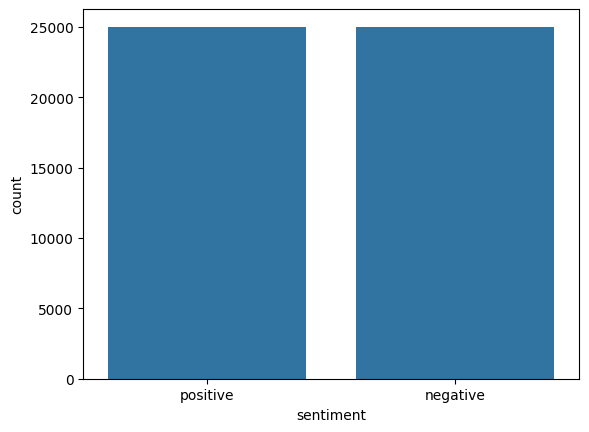

In [12]:
sns.countplot(data = df, x = df["sentiment"])
plt.show()

### Text Preprocessing

Applying a custom preprocessing function to clean the movie reviews. This includes removing HTML tags, punctuation, numbers, single characters, and stopwords. We also encode the sentiment to numerical values (0 for negative, 1 for positive).

In [13]:
# Apply the custom preprocessing function to the 'review' column to create a 'cleaned_review' column
df['cleaned_review'] = df['review'].apply(custom.preprocess_text)

# Encode the 'sentiment' column to numerical values (0 for negative, 1 for positive)
df['sentiment_encoded'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0) #LABEL ENCODER

print("First 5 rows with cleaned review and encoded sentiment:")
display(df.head())

First 5 rows with cleaned review and encoded sentiment:


,review,sentiment,cleaned_review,sentiment_encoded
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...,1


### Review Length Analysis

Comparing the distribution of original and cleaned review lengths to see the effect of preprocessing.

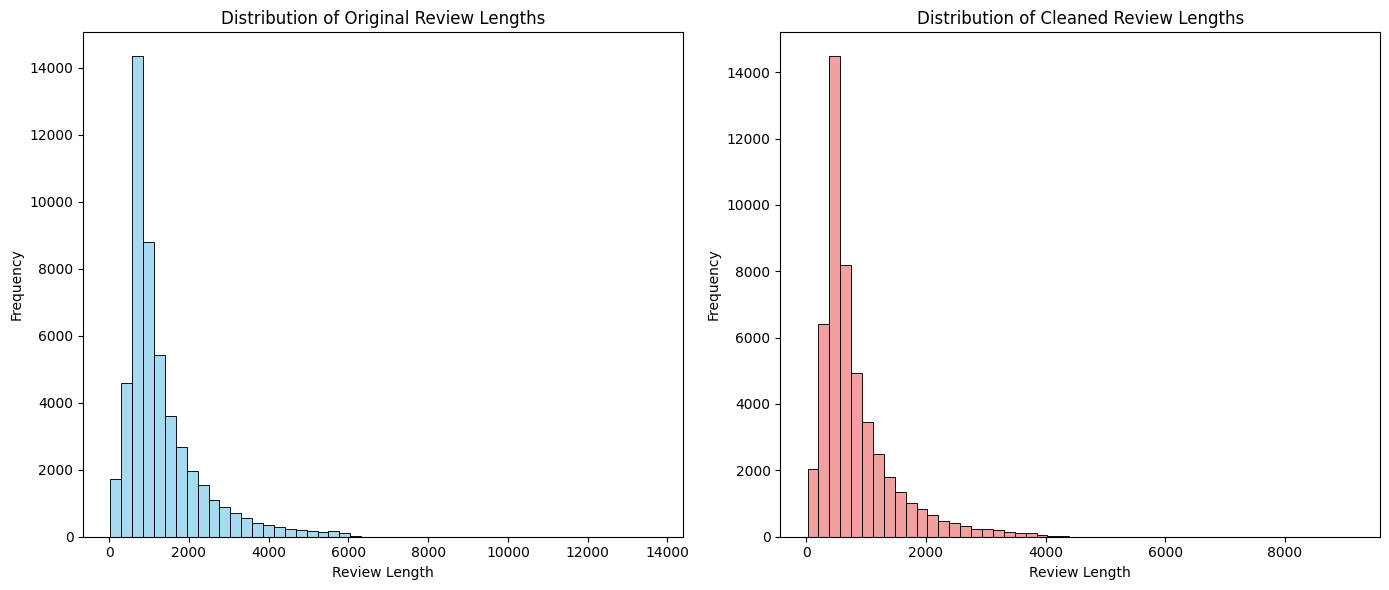

In [14]:
# Calculate the length of original reviews
df['original_review_length'] = df['review'].apply(len)
# Calculate the length of cleaned reviews
df['cleaned_review_length'] = df['cleaned_review'].apply(len)

plt.figure(figsize=(14, 6))

# Plot the distribution of original review lengths
plt.subplot(1, 2, 1)
sns.histplot(df['original_review_length'], bins=50, color='skyblue')
plt.title('Distribution of Original Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

# Plot the distribution of cleaned review lengths
plt.subplot(1, 2, 2)
sns.histplot(df['cleaned_review_length'], bins=50, color='lightcoral')
plt.title('Distribution of Cleaned Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The review length distribution is positively skewed, indicating that most reviews are relatively short while a smaller subset contains very long detailed opinions.

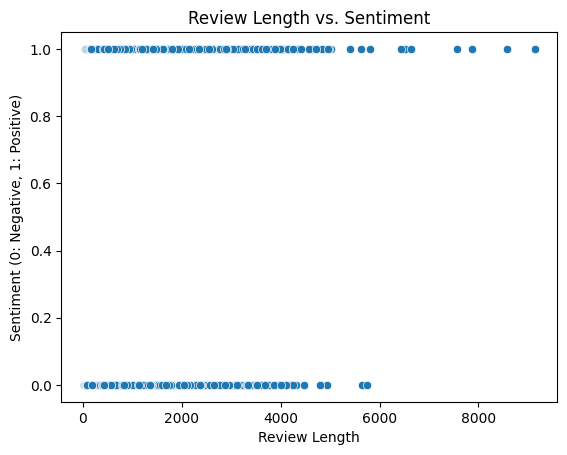

In [15]:
# Analyze if review length has a relationship with positive or negative sentiment
sns.scatterplot(data=df,x= df['cleaned_review_length'],y= df['sentiment_encoded'])
plt.title('Review Length vs. Sentiment')
plt.xlabel('Review Length')
plt.ylabel('Sentiment (0: Negative, 1: Positive)')
plt.show()

In [16]:
# Count the number of duplicated cleaned reviews
df['cleaned_review'].duplicated().sum()

np.int64(424)

In [17]:
# Remove duplicate rows based on the 'cleaned_review' column, keeping the first occurrence
df.drop_duplicates(subset=['cleaned_review'], inplace=True)
print(f"DataFrame shape after removing duplicates: {df.shape}")

DataFrame shape after removing duplicates: (49576, 6)


### Exploratory Data Analysis: Word Cloud of Common Words

A word cloud provides a visual representation of the most frequent words in our preprocessed reviews. This can give us insights into the common themes and topics.

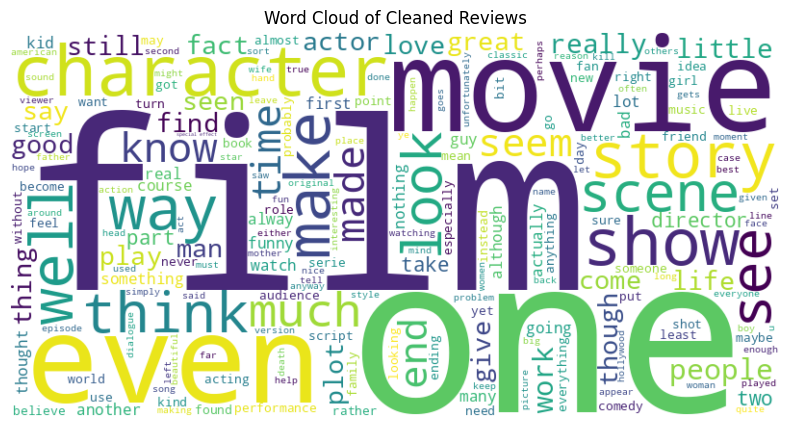

In [18]:
from wordcloud import WordCloud

# Combine all cleaned reviews into a single string
all_words = ' '.join(df['cleaned_review'].dropna())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Reviews')
plt.show()

### Feature Engineering: Tokenization Parameters for Traditional ML

Before training our machine learning models, we need to convert our text data into numerical features. For traditional models like Logistic Regression and SVM, we will use TF-IDF vectorization. First, we define the maximum number of words for our tokenizer and then prepare the data for splitting.

### Feature Engineering: Tokenization, Padding, and Train-Test Split

Now, let's prepare our text data for a deep learning model. This involves:
1.  **Splitting** the dataset into training and testing sets.
2.  **Tokenizing** the cleaned reviews to convert words into numerical representations.
3.  **Padding** the sequences to ensure all input sequences have a consistent length, which is required by neural networks.

In [19]:
# Separate features (X) and target (y)
X = df['cleaned_review']
y = df['sentiment_encoded']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (39660,)
Testing data shape: (9916,)


In [20]:
max_words = 15000  # Considering top 15,000 words for the tokenizer
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')

# Fit tokenizer on training texts to learn the vocabulary
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences of integers
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("Example of a tokenized review (first training sample):")
print(X_train_sequences[0][:10]) # Display first 10 tokens

Example of a tokenized review (first training sample):
[84, 7, 2, 36, 3677, 4007, 27, 41, 5, 35]


### TF-IDF Vectorization

Converting the text data into numerical TF-IDF (Term Frequency-Inverse Document Frequency) features. TF-IDF reflects how important a word is to a document in a corpus.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=20000,ngram_range=(1, 2))

# Fit on X_train and transform both X_train and X_test
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (39660, 20000)
Shape of X_test_tfidf: (9916, 20000)


### Model Evaluation Function

Defining a utility function to train a given model, make predictions, and report key performance metrics like accuracy, precision, recall, F1-score, and display a confusion matrix.

In [22]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, model_name,
                   X_train, X_test,
                   y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print results
    print(f"\n{'='*40}")
    print(f"{model_name}")
    print(f"{'='*40}")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6,5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

### Training Logistic Regression Model

Applying Logistic Regression, a simple yet effective linear model for binary classification, to our TF-IDF features.


Logistic Regression
Accuracy  : 0.9007
Precision : 0.8918
Recall    : 0.9127
F1 Score  : 0.9021


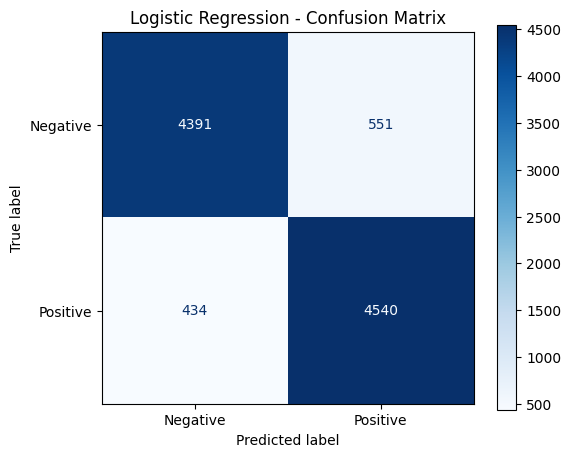

In [23]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced',penalty='l2',C=1)

log_result = evaluate_model(
    log_model,
    "Logistic Regression",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

### Training Support Vector Machine (SVM) Model

Applying a Linear Support Vector Classifier (LinearSVC) to the TF-IDF features.


SVM
Accuracy  : 0.8977
Precision : 0.8919
Recall    : 0.9059
F1 Score  : 0.8989


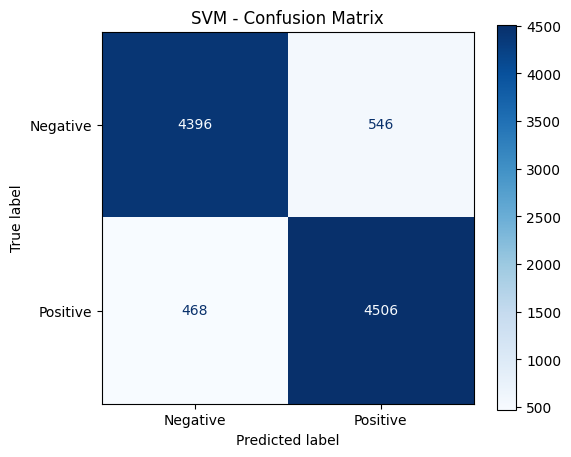

In [24]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_result = evaluate_model(
    svm_model,
    "SVM",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

### Hyperparameter Tuning for SVM using GridSearchCV

Optimizing the `C` parameter for the LinearSVC model using GridSearchCV to find the best performing hyperparameters.

In [25]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Parameters to search
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],
     "loss": ["hinge", "squared_hinge"],
    "class_weight": ["balanced"],
     "max_iter": [1000, 2000],
     "penalty": [ "l2"],
     "tol": [1e-3, 1e-4, 1e-5],

}

# Grid Search
grid_svm = GridSearchCV(
    estimator=LinearSVC(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train
grid_svm.fit(
    X_train_tfidf,
    y_train
)

# Results
print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest CV F1:")
print(grid_svm.best_score_)

Best Parameters:
{'C': 0.1, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 1000, 'penalty': 'l2', 'tol': 0.001}

Best CV F1:
0.9019648419196888


### Evaluating Optimized SVM Model

Training and evaluating the SVM model with the best hyperparameters found through GridSearchCV.


Optimized SVM
Accuracy  : 0.9016
Precision : 0.8920
Recall    : 0.9146
F1 Score  : 0.9031


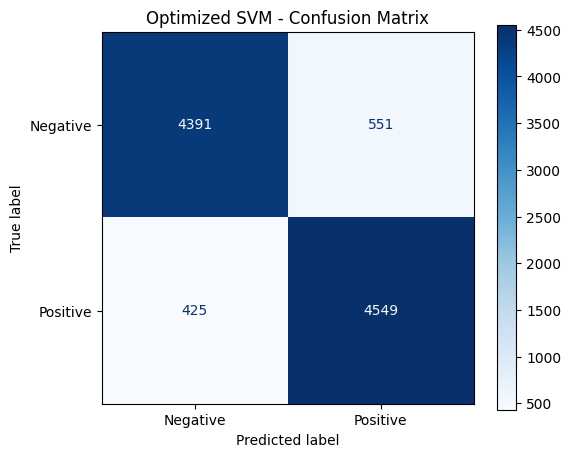

In [26]:
best_svm = LinearSVC(
    C=grid_svm.best_params_["C"],
    class_weight=grid_svm.best_params_["class_weight"],
    loss=grid_svm.best_params_["loss"],
    max_iter=grid_svm.best_params_["max_iter"],
    penalty=grid_svm.best_params_["penalty"],
    tol=grid_svm.best_params_["tol"],
    random_state=42

)

best_svm_result = evaluate_model(
    best_svm,
    "Optimized SVM",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)


KNN
Accuracy  : 0.7689
Precision : 0.7335
Recall    : 0.8470
F1 Score  : 0.7862


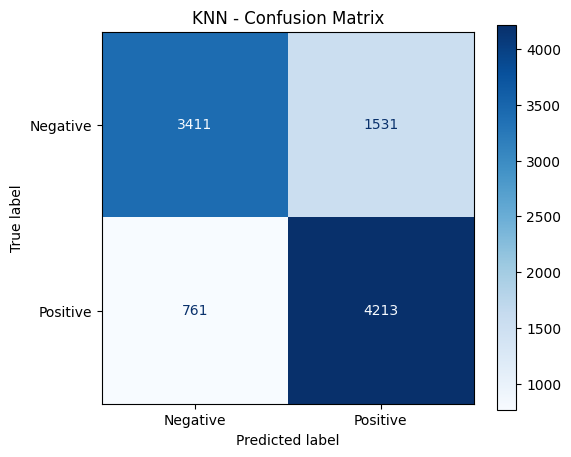

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_result = evaluate_model(
    knn_model,
    "KNN",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)


Random Forest
Accuracy  : 0.8547
Precision : 0.8527
Recall    : 0.8587
F1 Score  : 0.8557


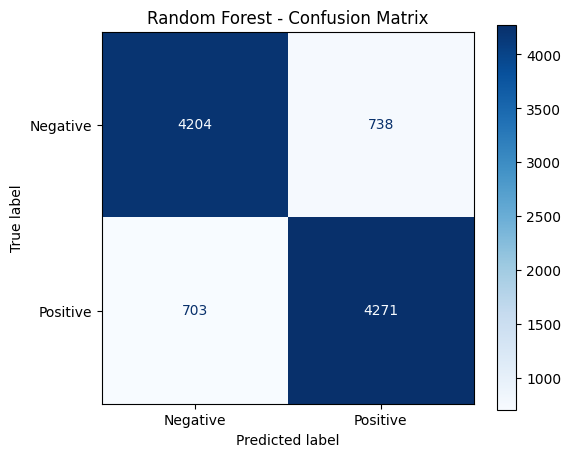

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_result = evaluate_model(
    rf_model,
    "Random Forest",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)


SGD
Accuracy  : 0.8989
Precision : 0.8850
Recall    : 0.9176
F1 Score  : 0.9010


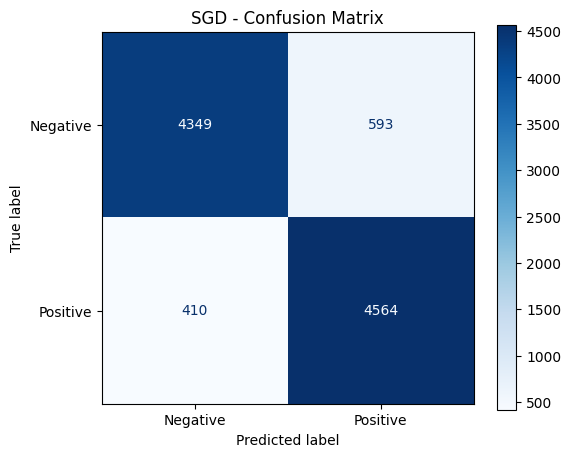

In [29]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(loss="hinge", penalty="l2", max_iter=1000,)

sgd_result = evaluate_model(
    sgd_model,
    "SGD",
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

### Comparing Model Performance

Presenting a summary of the F1-scores and other metrics for both Logistic Regression and the Optimized SVM.

### Model Analysis and Comparison

After training and evaluating multiple models, this section will provide a comparative analysis of their performance based on key metrics. We will also save all the trained models for future use.

In [30]:
final_results = pd.DataFrame([
    log_result,
    best_svm_result,
    knn_result,
    rf_result,
    sgd_result
])

print(
    final_results.sort_values(
        by="F1",
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall        F1
1        Optimized SVM  0.901573   0.891961  0.914556  0.903117
0  Logistic Regression  0.900666   0.891770  0.912746  0.902136
4                  SGD  0.898850   0.885011  0.917571  0.900997
3        Random Forest  0.854679   0.852665  0.858665  0.855655
2                  KNN  0.768858   0.733461  0.847004  0.786154


### Calculating Improvement

Quantifying the improvement in F1-score of the optimized SVM over the baseline Logistic Regression model.

In [31]:
improvement = (
    (best_svm_result["F1"] - rf_result["F1"])
    / rf_result["F1"]
) * 100

print(f"Improvement: {improvement:.2f}%")

Improvement: 5.55%


### Saving the Trained Model and Vectorizer

Persisting the best performing model (Optimized SVM) and the TF-IDF vectorizer to disk for future use, avoiding retraining.

In [32]:
# Calculate the lengths of the tokenized training sequences
review_lengths = [len(x) for x in X_train_sequences]

# Print the 90th and 95th percentiles of review lengths
print(f"90th percentile of review lengths: {np.percentile(review_lengths, 90)}")
print(f"95th percentile of review lengths: {np.percentile(review_lengths, 95)}")

90th percentile of review lengths: 237.0
95th percentile of review lengths: 311.0


95% of reviews were under 350 tokens,
therefore max_len=350 was selected.

Long reviews increase:

* memory usage
* training time
* padding inefficiency

### Padding Sequences

Ensuring all sequences have a uniform length by padding or truncating them. This is crucial for neural network inputs.

In [33]:
def preprocess_for_dl(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove html tags
    text = remove_tags(text)
    # Remove punctuations and numbers
    text = re.sub('[^a-zA-Z]', ' ', text)
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)
    return text

# Apply the preprocessing specifically for deep learning models (without stopword removal)
df['dl_review'] = df['review'].apply(preprocess_for_dl)

In [34]:
# Separate features (X_dl) and target (y_dl) for deep learning models
X_dl = df['dl_review']
y_dl = df['sentiment_encoded']

# Split the data into training and testing sets for deep learning models
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y_dl, test_size=0.2, random_state=42
)

In [35]:
max_words = 10000 # Define the maximum number of words for the deep learning tokenizer
tokenizer_dl = Tokenizer(num_words=max_words, oov_token='<OOV>')
# Fit the tokenizer on the training data
tokenizer_dl.fit_on_texts(X_train_dl)

# Convert text reviews to sequences of integers
X_train_seq = tokenizer_dl.texts_to_sequences(X_train_dl)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test_dl)

In [36]:
max_len = 350 # Define the maximum sequence length for padding

# Pad training sequences to ensure uniform length
X_train_padded = pad_sequences(
    X_train_seq, maxlen=max_len, padding='post', truncating='post'
)

# Pad testing sequences to ensure uniform length
X_test_padded = pad_sequences(
    X_test_seq, maxlen=max_len, padding='post', truncating='post'
)

In [37]:
vocab_size = max_words; # Vocabulary size is the maximum number of words considered
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 10000


In [38]:
# # Determine maximum sequence length
# max_len_org = max([len(x) for x in X_train_sequences])
# print(f"Maximum sequence length in training data: {max_len_org}")

# max_len=350;

# # Pad sequences to ensure uniform length
# X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
# X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')

# print(f"Shape of padded training sequences: {X_train_padded.shape}")
# print(f"Shape of padded testing sequences: {X_test_padded.shape}")
# print("Example of a padded review (first training sample):")
# print(X_train_padded[0]);

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import numpy as np


def evaluate_dl_model(
    model,
    model_name,
    X_train,
    X_test,
    y_train,
    y_test,
    epochs=5,
    batch_size=128,
    callbacks=None, # Added callbacks parameter
):

    # =========================
    # Train the deep learning model
    # =========================

    history = model.fit(

        X_train,
        y_train,

        validation_split=0.2,

        epochs=epochs,

        batch_size=batch_size,

        verbose=1,
        callbacks=callbacks # Pass callbacks to model.fit
    )

    # =========================
    # Predict probabilities on the test set
    # =========================

    pred_probs = model.predict(X_test)

    # Convert probabilities to binary predictions (0 or 1)
    preds = (
        pred_probs > 0.5
    ).astype(int)

    preds = preds.flatten()

    # =========================
    # Calculate and print evaluation metrics
    # =========================

    accuracy = accuracy_score(
        y_test,
        preds
    )

    precision = precision_score(
        y_test,
        preds
    )

    recall = recall_score(
        y_test,
        preds
    )

    f1 = f1_score(
        y_test,
        preds
    )

    print(f"\n{'='*40}")
    print(model_name)
    print(f"{'='*40}")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # =========================
    # Plot Confusion Matrix
    # =========================

    cm = confusion_matrix(
        y_test,
        preds
    )

    fig, ax = plt.subplots(
        figsize=(6,5)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.show()

    # =========================
    # Plot Training and Validation Accuracy over epochs
    # =========================

    plt.plot(
        history.history['accuracy']
    )

    plt.plot(
        history.history['val_accuracy']
    )

    plt.title(
        f"{model_name} Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend([
        'Train',
        'Validation'
    ])

    plt.show()

    # =========================
    # Plot Training and Validation Loss over epochs
    # =========================

    plt.plot(
        history.history['loss']
    )

    plt.plot(
        history.history['val_loss']
    )

    plt.title(
        f"{model_name} Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend([
        'Train',
        'Validation'
    ])

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

def build_conv1d_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.7640 - loss: 0.4760 - val_accuracy: 0.8739 - val_loss: 0.3005
Epoch 2/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9071 - loss: 0.2448 - val_accuracy: 0.8883 - val_loss: 0.2656
Epoch 3/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9583 - loss: 0.1275 - val_accuracy: 0.8912 - val_loss: 0.2857
Epoch 4/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9883 - loss: 0.0500 - val_accuracy: 0.8933 - val_loss: 0.3262
Epoch 5/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9966 - loss: 0.0189 - val_accuracy: 0.8938 - val_loss: 0.3828
310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Conv1D
Accuracy  : 0.8911
Precision : 0.9178
Recall    : 0.8599
F1 Score  : 0.8879


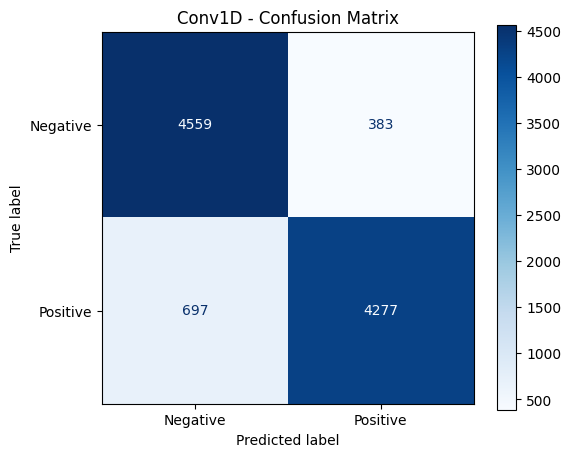

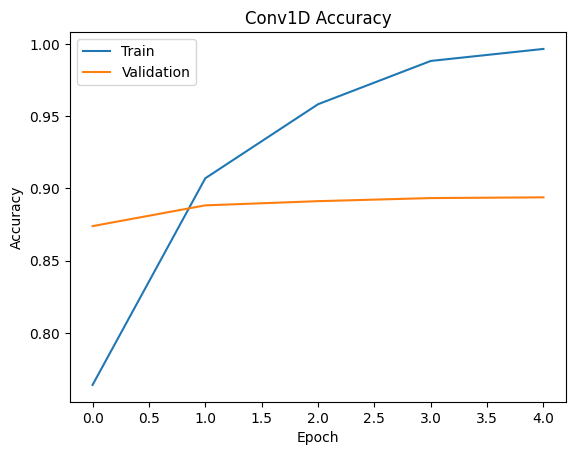

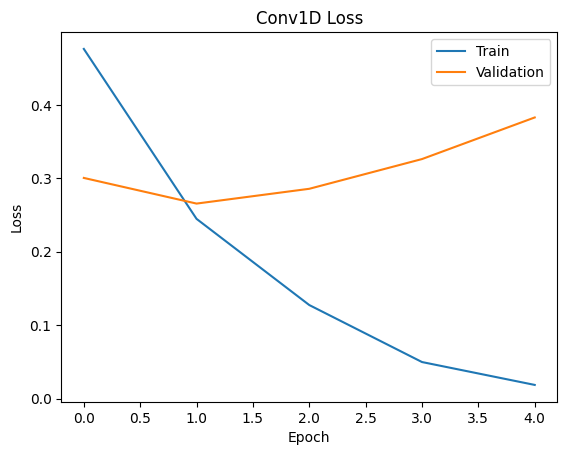

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Build the Conv1D model
conv_model = build_conv1d_model()

conv_result = evaluate_dl_model(
    conv_model, "Conv1D",
    X_train_padded, X_test_padded,
    y_train_dl, y_test_dl,
    epochs=15, batch_size=128,
    callbacks=[early_stop]        # Pass the early stopping callback
)

### Fixed LSTM Model

**Issues in the original LSTM:**
- Single-direction LSTM misses backward context — important for sentiment
- No recurrent dropout (causes overfitting on sequences)
- Dropout placed *after* LSTM but not *inside* it
- `input_length` argument is deprecated in newer Keras (causes a warning)
- 20 epochs with patience=3 is fine but the model was underfitting anyway

**Fixes applied:**
- `Bidirectional(LSTM(...))` — reads text both left→right and right→left
- `recurrent_dropout=0.2` inside LSTM — regularizes hidden state updates
- Removed deprecated `input_length` kwarg
- Kept `EarlyStopping` with `restore_best_weights=True`

In [44]:
from tensorflow.keras.layers import Bidirectional, SpatialDropout1D

def build_lstm_model_fixed():
    model = Sequential([
        # Embedding: vocab_size tokens -> 128-d vectors
        Embedding(input_dim=vocab_size, output_dim=128),

        # SpatialDropout1D: drops whole embedding channels (better than
        # Dropout for embeddings - keeps sequence structure intact)
        SpatialDropout1D(0.3),

        # Bidirectional: 64 units each direction -> 128-d output
        # NO recurrent_dropout here - use SpatialDropout1D instead
        Bidirectional(LSTM(64, return_sequences=False)),

        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()
    return model

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.7460 - loss: 0.4988 - val_accuracy: 0.8177 - val_loss: 0.4249 - learning_rate: 0.0010
Epoch 2/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.8826 - loss: 0.3084 - val_accuracy: 0.8669 - val_loss: 0.3318 - learning_rate: 0.0010
Epoch 3/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9145 - loss: 0.2348 - val_accuracy: 0.8826 - val_loss: 0.3037 - learning_rate: 0.0010
Epoch 4/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9232 - loss: 0.2097 - val_accuracy: 0.8695 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 5/15
247/248 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9337 - loss: 0.1834
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.9309 - loss: 0.1867 - val_accuracy: 0.8748 - val_loss: 0.3308 - learning_rate: 0.0010
Epoch 6/15
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9541 - los

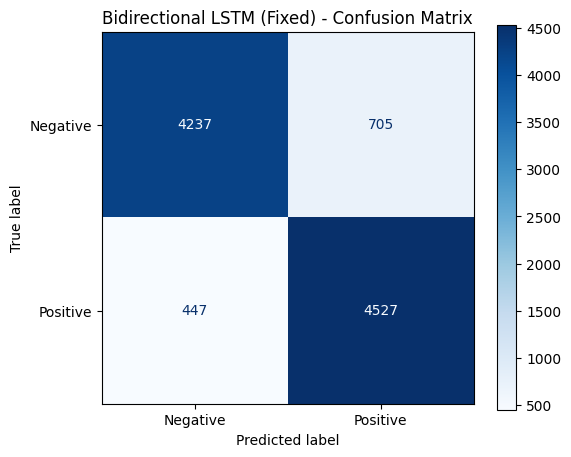

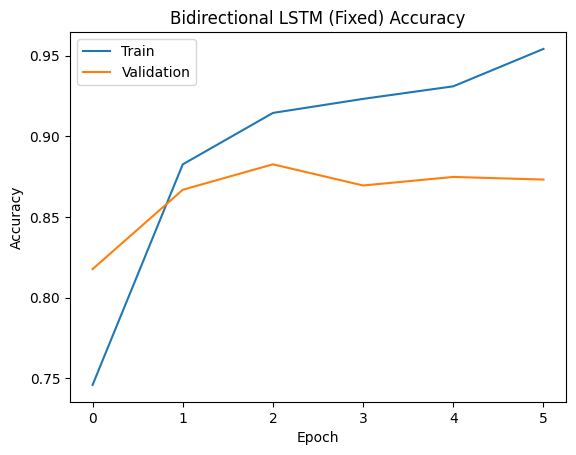

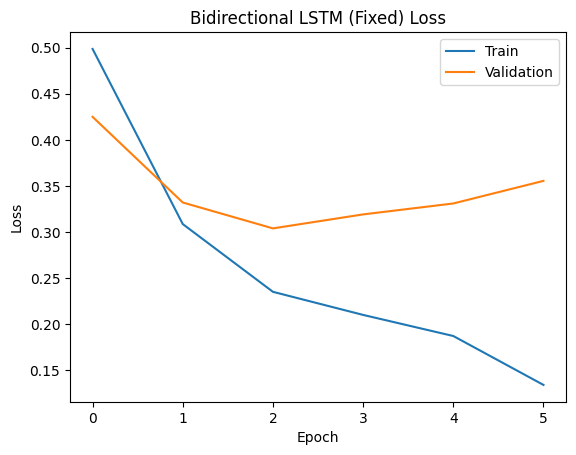

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

lstm_model_fixed = build_lstm_model_fixed()

lstm_fixed_result = evaluate_dl_model(
    lstm_model_fixed,
    "Bidirectional LSTM (Fixed)",
    X_train_padded,
    X_test_padded,
    y_train_dl,
    y_test_dl,
    epochs=15,
    batch_size=128,
    callbacks=[early_stop, reduce_lr]
)

### Modern Method 1 — Conv1D + Bidirectional LSTM Hybrid

Combining a `Conv1D` (fast local n-gram extraction) with a `Bidirectional LSTM` (long-range context) gives the best of both worlds:
- Conv1D acts as a **feature extractor** / dimensionality reducer before the LSTM
- BiLSTM captures **sequential dependencies** in both directions
- This hybrid regularly outperforms standalone Conv1D or LSTM on text classification


In [48]:
from tensorflow.keras.layers import Bidirectional, SpatialDropout1D

def build_conv_bilstm_model():
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128),

        # Regularise embedding dimensions (GPU-safe)
        SpatialDropout1D(0.3),

        # Conv1D: extract local n-gram features
        Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
        Dropout(0.3),

        # BiLSTM: NO recurrent_dropout (kills GPU)
        Bidirectional(LSTM(64, return_sequences=False)),

        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.summary()
    return model

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
496/496 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.7288 - loss: 0.5385 - val_accuracy: 0.7400 - val_loss: 0.5279 - learning_rate: 0.0010
Epoch 2/25
496/496 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.8397 - loss: 0.3903 - val_accuracy: 0.8904 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 3/25
496/496 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9078 - loss: 0.2528 - val_accuracy: 0.8941 - val_loss: 0.2685 - learning_rate: 0.0010
Epoch 4/25
496/496 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9287 - loss: 0.1993 - val_accuracy: 0.8989 - val_loss: 0.2800 - learning_rate: 0.0010
Epoch 5/25
496/496 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9474 - loss: 0.1636 - val_accuracy: 0.8835 - val_loss: 0.3021 - learning_rate: 0.0010
Epoch 6/25
495/496 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9605 - loss: 0.1337
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
496/496 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9589 - los

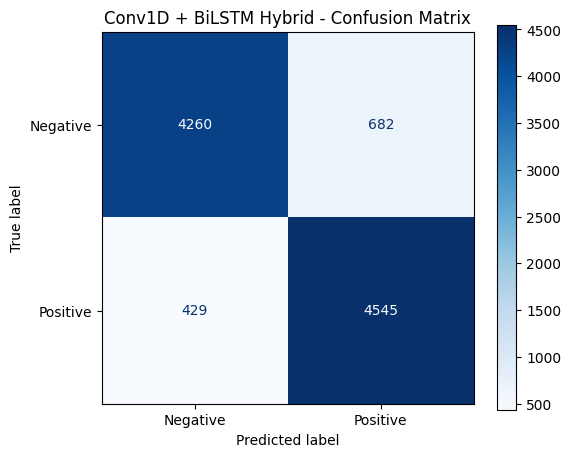

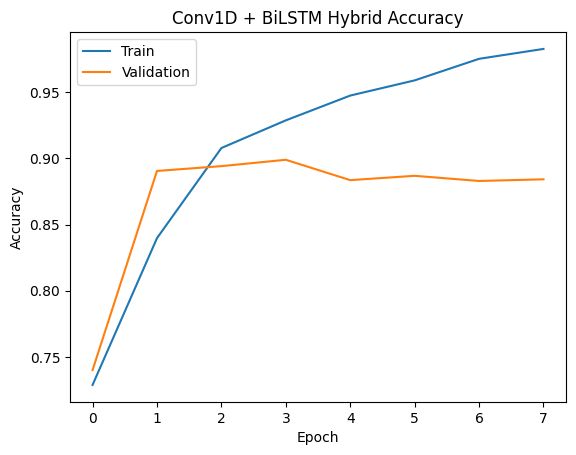

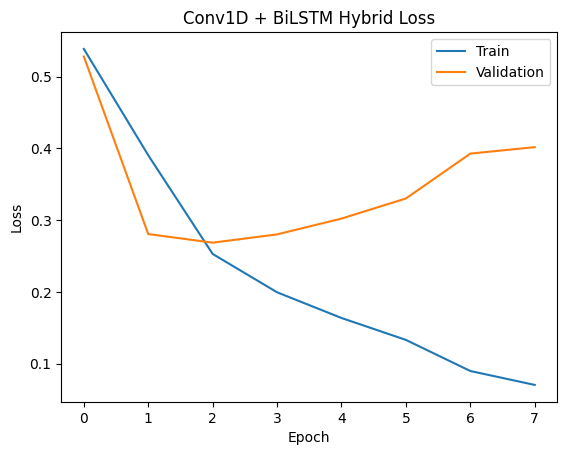

In [50]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

conv_bilstm_model = build_conv_bilstm_model()

conv_bilstm_result = evaluate_dl_model(
    conv_bilstm_model,
    "Conv1D + BiLSTM Hybrid",
    X_train_padded,
    X_test_padded,
    y_train_dl,
    y_test_dl,
    epochs=25,        # more room to improve
    batch_size=64,    # smaller batch = better generalization
    callbacks=[early_stop, reduce_lr]
)

### Final Model Comparison — All Methods

In [52]:
# Collect all DL results (add your conv_result if Conv1D was already run)
dl_results = pd.DataFrame([
    conv_result,           # Conv1D (baseline DL)
    lstm_fixed_result,     # Fixed Bidirectional LSTM
    conv_bilstm_result,    # Conv1D + BiLSTM Hybrid
])

print("\n=== Deep Learning Model Comparison ===")
print(dl_results.sort_values(by='F1', ascending=False).to_string(index=False))




=== Deep Learning Model Comparison ===
                     Model  Accuracy  Precision   Recall       F1
    Conv1D + BiLSTM Hybrid  0.887959   0.869524 0.913752 0.891089
                    Conv1D  0.891085   0.917811 0.859871 0.887897
Bidirectional LSTM (Fixed)  0.883824   0.865252 0.910133 0.887125


### Save All Models

In [53]:
import joblib

# Save traditional models
joblib.dump(log_model,        "logistic_regression_sentiment_v2.pkl")
joblib.dump(best_svm,         "optimized_svm_sentiment_v2.pkl")
joblib.dump(knn_model,        "knn_sentiment_v2.pkl")
joblib.dump(rf_model,         "random_forest_sentiment_v2.pkl")
joblib.dump(sgd_model,        "sgd_sentiment_v2.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer_negation_v2.pkl")

# Save deep learning models
conv_model.save("conv1d_sentiment_model_v3.keras")
lstm_model_fixed.save("bilstm_sentiment_model_v3.keras")
conv_bilstm_model.save("conv_bilstm_sentiment_model_v3.keras")

print("All models saved successfully.")
print("Note: using .keras format instead of deprecated .h5")


All models saved successfully.
Note: using .keras format instead of deprecated .h5
